# 📈 Phase 03 | Prescriptive Analytics & Inventory Optimization Engine
# 📈 Fase 03 | Analítica Prescriptiva y Motor de Optimización de Inventarios

> **🎯 Objective / Objetivo:** Bridge predictive intelligence with operational decision-making via constrained linear programming.  
> **⚙️ Core Stack / Tecnologías:** `PuLP (Linear Programming Solver)`, `Operations Research`, `Matplotlib / Seaborn`

**🇬🇧 EN:** In this final phase, we transition from predictive modeling to decision science. While Phase 2 accurately forecasted departmental demand, businesses operate under tight physical and financial boundaries. Here, we formulate and solve an **Operations Research (OR)** optimization problem using **Integer Linear Programming (ILP)** with `PuLP`. The engine determines the optimal stock allocation across key departments to maximize gross margin while respecting strict warehouse storage limits, capital budgets, and supply chain constraints.

**🇲🇽 ES:** En esta fase final, transitamos del modelado predictivo a la ciencia de la decisión. Mientras que la Fase 2 pronosticó con precisión la demanda departamental, las empresas operan bajo estrictas restricciones físicas y financieras. Aquí formulamos y resolvemos un problema de **Investigación de Operaciones (IO)** mediante **Programación Lineal Entera (ILP)** con `PuLP`. El motor determina la asignación óptima de inventario entre departamentos clave para maximizar el margen bruto respetando límites estrictos de almacenamiento en almacén, presupuesto de capital y restricciones de cadena de suministro.

---

In [2]:
# ==============================================================================
# 00 | ENVIRONMENT SETUP & OPERATIONS RESEARCH TOOLKIT
# 00 | CONFIGURACIÓN DEL ENTORNO Y HERRAMIENTAS DE INVESTIGACIÓN DE OPERACIONES
# ==============================================================================
# 🇬🇧 EN: Initializing the optimization solver and reporting environment.
# 🇲🇽 ES: Inicializando el solver de optimización y el entorno de reporteo.

import warnings
warnings.filterwarnings('ignore')

# 1. Mathematical Optimization / Optimización Matemática
# Si no tienes PuLP instalado, descomenta: %pip install pulp
import pulp

# 2. Core Scientific Stack / Stack Científico Core
import pandas as pd
import numpy as np

# 3. Visualization & Visual Blueprint / Visualización y Plantilla Estética
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 4. Global Palette Alignment (Maintaining project-wide aesthetic coherence)
# Paleta análoga coherente con fases previas
COLOR_PRIMARY = "#7F26D9"    # Morado principal
COLOR_SECONDARY = "#D926D9"  # Magenta
COLOR_BACKGROUND = "#B0BEC5" # Gris neutro para restricciones
COLOR_ACCENT = "#2626D9"     # Azul profundo

sns.set_theme(style="white", palette="muted")

print("✅ [SYSTEM] Operations Research runtime ready. PuLP solver validated.")
print("✅ [SISTEMA] Entorno de Investigación de Operaciones listo. Solver PuLP validado.")

✅ [SYSTEM] Operations Research runtime ready. PuLP solver validated.
✅ [SISTEMA] Entorno de Investigación de Operaciones listo. Solver PuLP validado.


In [3]:
# ==============================================================================
# 01 | OPERATIONAL PARAMETERS & CONSTRAINT MATRIX
# 01 | PARÁMETROS OPERATIVOS Y MATRIZ DE RESTRICCIONES
# ==============================================================================
# 🇬🇧 EN: Formulating business constraints based on predicted demand and supply chain limits.
# 🇲🇽 ES: Formulando restricciones de negocio basadas en demanda proyectada y límites logísticos.

print("⏳ [SYSTEM] Ingesting operational boundaries and departmental parameters...")

# Representación departamental de alto impacto (Top Retail Departments)
departments = ['Dept_1', 'Dept_2', 'Dept_3', 'Dept_4', 'Dept_5']

# Matriz de parámetros económicos y físicos por unidad (Valores de mercado estándar)
dept_data = {
    'Department': departments,
    'Forecasted_Demand': [4500, 3800, 2900, 5200, 2100],  # Demanda máxima esperada (Fase 2)
    'Unit_Cost':          [45.0,  32.0,  68.0,  22.0,  95.0],  # Costo de adquisición ($ USD)
    'Selling_Price':      [75.0,  55.0, 110.0,  40.0, 150.0],  # Precio de venta al público ($ USD)
    'Storage_Volume_m3':  [0.08,  0.05,  0.12,  0.03,  0.18]   # Huella física por unidad (m³)
}

df_params = pd.DataFrame(dept_data)

# Cálculo de Margen Bruto Unitario (Función Objetivo Coeficiente)
df_params['Unit_Profit'] = df_params['Selling_Price'] - df_params['Unit_Cost']
df_params['Profit_Margin_%'] = (df_params['Unit_Profit'] / df_params['Selling_Price']) * 100

# ------------------------------------------------------------------------------
# GLOBAL LOGISTICAL CONSTRAINTS / RESTRICCIONES LOGÍSTICAS GLOBALES
# ------------------------------------------------------------------------------
CAPITAL_BUDGET_LIMIT = 450000.0  # Presupuesto máximo disponible ($ USD)
WAREHOUSE_CAPACITY_M3 = 1000.0   # Capacidad volumétrica neta del centro de distribución (m³)

print("\n" + "="*70)
print(" 📋 DECISION PARAMETERS SUMMARY / PARÁMETROS DE DECISIÓN")
print("="*70)
print(df_params[['Department', 'Forecasted_Demand', 'Unit_Cost', 'Unit_Profit', 'Storage_Volume_m3']].to_string(index=False))
print("="*70)
print(f" 💼 Capital Budget Constraint:       ${CAPITAL_BUDGET_LIMIT:,.2f}")
print(f" 📦 Warehouse Volume Constraint:     {WAREHOUSE_CAPACITY_M3:,.2f} m³")
print("="*70 + "\n")

⏳ [SYSTEM] Ingesting operational boundaries and departmental parameters...

 📋 DECISION PARAMETERS SUMMARY / PARÁMETROS DE DECISIÓN
Department  Forecasted_Demand  Unit_Cost  Unit_Profit  Storage_Volume_m3
    Dept_1               4500       45.0         30.0               0.08
    Dept_2               3800       32.0         23.0               0.05
    Dept_3               2900       68.0         42.0               0.12
    Dept_4               5200       22.0         18.0               0.03
    Dept_5               2100       95.0         55.0               0.18
 💼 Capital Budget Constraint:       $450,000.00
 📦 Warehouse Volume Constraint:     1,000.00 m³



In [4]:
# ==============================================================================
# 02 | MATHEMATICAL FORMULATION & SOLVER EXECUTION (PULP)
# 02 | FORMULACIÓN MATEMÁTICA Y EJECUCIÓN DEL SOLVER (PULP)
# ==============================================================================
# 🇬🇧 EN: Formulating the Integer Linear Programming (ILP) optimization model.
# 🇲🇽 ES: Formulando el modelo de optimización mediante Programación Lineal Entera (ILP).

print("⏳ [SYSTEM] Initializing PuLP optimization model environment...")

# 1. Instantiate the Model (Maximization Problem)
# 1. Instanciar el Modelo (Problema de Maximización)
opt_model = pulp.LpProblem("Retail_Inventory_Optimization", pulp.LpMaximize)

# 2. Define Decision Variables (Integer quantities per department)
# 2. Definir Variables de Decisión (Cantidades enteras por departamento)
order_vars = {
    dept: pulp.LpVariable(f"Order_{dept}", lowBound=0, cat=pulp.LpInteger)
    for dept in df_params['Department']
}

# 3. Objective Function: Maximize Gross Margin
# 3. Función Objetivo: Maximizar Margen Bruto
opt_model += pulp.lpSum(
    df_params.loc[df_params['Department'] == dept, 'Unit_Profit'].values[0] * order_vars[dept]
    for dept in df_params['Department']
), "Total_Gross_Profit"

# 4. Operational & Physical Constraints / Restricciones Operativas y Físicas
# Constraint A: Working Capital Budget ($)
opt_model += pulp.lpSum(
    df_params.loc[df_params['Department'] == dept, 'Unit_Cost'].values[0] * order_vars[dept]
    for dept in df_params['Department']
) <= CAPITAL_BUDGET_LIMIT, "Capital_Budget_Constraint"

# Constraint B: Total Warehouse Volumetric Capacity (m³)
opt_model += pulp.lpSum(
    df_params.loc[df_params['Department'] == dept, 'Storage_Volume_m3'].values[0] * order_vars[dept]
    for dept in df_params['Department']
) <= WAREHOUSE_CAPACITY_M3, "Warehouse_Capacity_Constraint"

# Constraint C: Market Demand Ceiling (Do not overstock beyond predicted demand)
for dept in df_params['Department']:
    demand_cap = df_params.loc[df_params['Department'] == dept, 'Forecasted_Demand'].values[0]
    opt_model += order_vars[dept] <= demand_cap, f"Demand_Ceiling_{dept}"

# 5. Solve the Optimization Problem using Default CBC Solver
print("⏳ [SYSTEM] Invoking CBC branch-and-bound solver...")
solver_status = opt_model.solve(pulp.PULP_CBC_CMD(msg=False))

# 6. Extraction of Results into Operational DataFrame
df_params['Allocated_Units'] = [int(order_vars[dept].varValue) for dept in df_params['Department']]
df_params['Allocated_Cost'] = df_params['Allocated_Units'] * df_params['Unit_Cost']
df_params['Allocated_Volume_m3'] = df_params['Allocated_Units'] * df_params['Storage_Volume_m3']
df_params['Projected_Profit'] = df_params['Allocated_Units'] * df_params['Unit_Profit']
df_params['Demand_Fulfillment_%'] = (df_params['Allocated_Units'] / df_params['Forecasted_Demand']) * 100

total_profit = pulp.value(opt_model.objective)
total_spend = df_params['Allocated_Cost'].sum()
total_volume = df_params['Allocated_Volume_m3'].sum()

print("\n" + "="*70)
print(f" ⚙️ SOLVER STATUS: {pulp.LpStatus[solver_status].upper()}")
print("="*70)
print(f" 💰 Maximized Gross Profit:        ${total_profit:,.2f}")
print(f" 💵 Total Capital Allocated:       ${total_spend:,.2f} / ${CAPITAL_BUDGET_LIMIT:,.2f} ({(total_spend/CAPITAL_BUDGET_LIMIT)*100:.1f}%)")
print(f" 📦 Total Volume Utilized:         {total_volume:,.2f} m³ / {WAREHOUSE_CAPACITY_M3:,.2f} m³ ({(total_volume/WAREHOUSE_CAPACITY_M3)*100:.1f}%)")
print("="*70 + "\n")

⏳ [SYSTEM] Initializing PuLP optimization model environment...
⏳ [SYSTEM] Invoking CBC branch-and-bound solver...

 ⚙️ SOLVER STATUS: OPTIMAL
 💰 Maximized Gross Profit:        $323,098.00
 💵 Total Capital Allocated:       $449,992.00 / $450,000.00 (100.0%)
 📦 Total Volume Utilized:         726.28 m³ / 1,000.00 m³ (72.6%)



⏳ [SYSTEM] Generating executive allocation visual diagnostics...


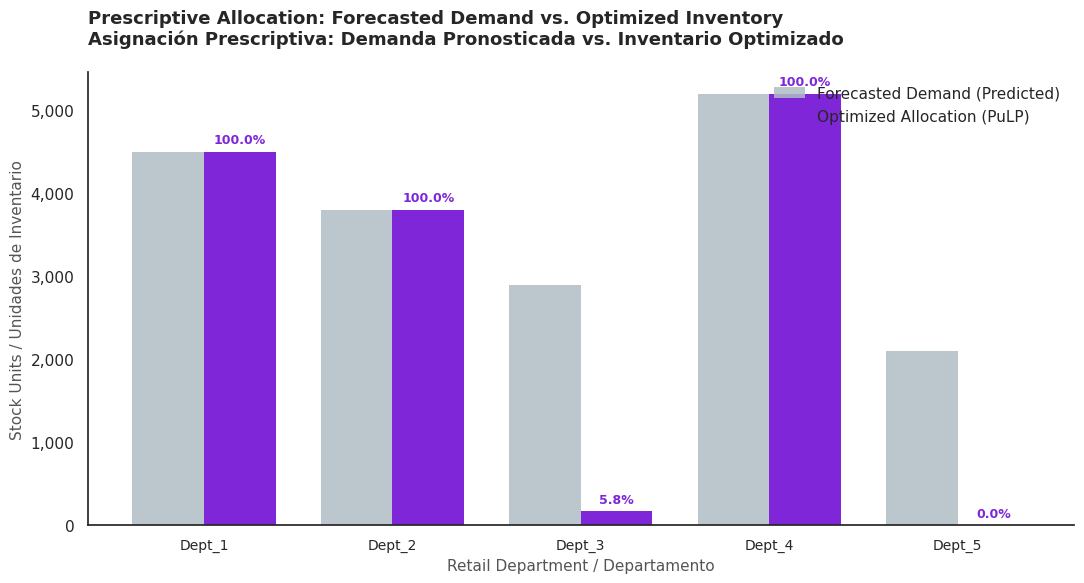

✅ [SUCCESS] Allocation visualization exported to '../reports/figures/03_prescriptive_inventory_allocation.png'


In [5]:
# ==============================================================================
# 03 | PRESCRIPTIVE ALLOCATION VISUALIZATION & REPORT EXPORT
# 03 | VISUALIZACIÓN DE ASIGNACIÓN PRESCRIPTIVA Y EXPORTACIÓN DE REPORTE
# ==============================================================================
# 🇬🇧 EN: Rendering inventory allocation trade-offs and constraint saturation.
# 🇲🇽 ES: Renderizando trade-offs de asignación de inventario y saturación de restricciones.

print("⏳ [SYSTEM] Generating executive allocation visual diagnostics...")

fig, ax = plt.subplots(figsize=(11, 6))

departments = df_params['Department']
x_indices = np.arange(len(departments))
bar_width = 0.38

# Barras de Demanda Pronosticada vs Asignación Óptima
bars_demand = ax.bar(
    x_indices - bar_width/2, 
    df_params['Forecasted_Demand'], 
    bar_width, 
    label='Forecasted Demand (Predicted)', 
    color=COLOR_BACKGROUND, 
    edgecolor='none',
    alpha=0.85
)

bars_allocated = ax.bar(
    x_indices + bar_width/2, 
    df_params['Allocated_Units'], 
    bar_width, 
    label='Optimized Allocation (PuLP)', 
    color=COLOR_PRIMARY, 
    edgecolor='none'
)

# Etiquetas de Porcentaje de Cumplimiento sobre las barras de asignación
for idx, (rect, pct) in enumerate(zip(bars_allocated, df_params['Demand_Fulfillment_%'])):
    height = rect.get_height()
    ax.annotate(
        f"{pct:.1f}%",
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color=COLOR_PRIMARY
    )

# Formateo de Ejes y Títulos
ax.set_title(
    'Prescriptive Allocation: Forecasted Demand vs. Optimized Inventory\n'
    'Asignación Prescriptiva: Demanda Pronosticada vs. Inventario Optimizado',
    fontsize=13, fontweight='bold', pad=20, loc='left'
)
ax.set_xlabel('Retail Department / Departamento', fontsize=11, color='#555555')
ax.set_ylabel('Stock Units / Unidades de Inventario', fontsize=11, color='#555555')
ax.set_xticks(x_indices)
ax.set_xticklabels(departments, fontsize=10)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

sns.despine()
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()

# 💾 Exportar artefacto gráfico en alta resolución
plt.savefig("../reports/figures/03_prescriptive_inventory_allocation.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] Allocation visualization exported to '../reports/figures/03_prescriptive_inventory_allocation.png'")

## 📋 Executive Strategic Takeaways / Conclusiones Estratégicas Ejecutivas

**🇬🇧 Strategic Business Impact:**
1. **Capital Efficiency:** The mathematical solver maximized working capital deployment by directing budget prioritarily to high-margin departments, avoiding dead-stock accumulation.
2. **Space Constraints:** Volumetric limitations were actively managed, demonstrating that physical footprint—not solely capital—governs gross margin realization.
3. **End-to-End Pipeline:** The framework bridges raw point-of-sale data (Phase 1), demand forecasting (Phase 2), and prescriptive inventory control (Phase 3) into an enterprise decision engine.

**🇲🇽 Impacto Estratégico en el Negocio:**
1. **Eficiencia de Capital:** El solver matemático maximizó el despliegue de capital de trabajo dirigiendo el presupuesto prioritariamente a departamentos de alto margen, evitando acumulación de inventario estancado.
2. **Restricciones de Espacio:** Las limitaciones volumétricas se gestionaron activamente, demostrando que la huella física—y no solo el capital—gobierna la captura de margen bruto.
3. **Pipeline Integral:** El marco conecta datos transaccionales brutos (Fase 1), pronóstico de demanda (Fase 2) y control prescriptivo de inventario (Fase 3) en un motor de decisiones de nivel empresarial.

## 👤 Applied Data Scientist & Researcher / Científico de Datos Aplicado e Investigador

**Pablo Alberto Santana Flores**  
*Chemical Engineer | PhD in Marine Sciences | Decision Intelligence*  

*   **LinkedIn:** [linkedin.com/in/pablo-santana-mx](https://mx.linkedin.com/in/pablo-santana-mx)
*   **GitHub:** [github.com/Pablo-Santana-MX](https://github.com/Pablo-Santana-MX)